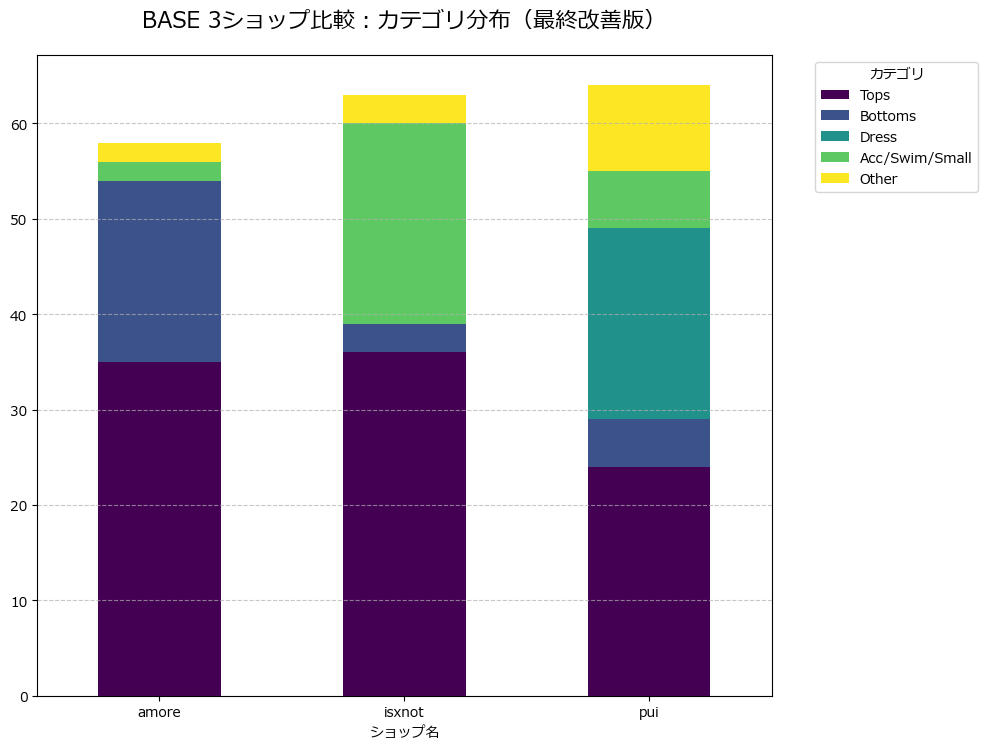

分析対象数: 185件
▼ まだ'Other'に残っている商品
['PUI BORDER VINTAGE RED', 'PUI BORDER NEVY', 'HOTEL BENOITE BIG TOTE', 'HOTEL BENOITE TOTE', 'ROSE DE DAMAS アロマティックナチュレソープ', 'ROSE DE DAMAS オーガニックシュガースクラブ', 'LOGO CHARM', 'Emma Cocarne ヘアオイル', 'NOVELTY (THE SUNDAY ROMANTIC)', 'ポストカード', 'サンドビーニー / NRK 26summer']


In [2]:
# --- 修正版：分析コード ---
import pandas as pd
import matplotlib.pyplot as plt
import re
import unicodedata

# 1. データの読み込み
df = pd.read_csv("combined_base_data.csv")

# 文字の掃除
def clean_text(text):
    text = unicodedata.normalize('NFKC', str(text))
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['商品名'] = df['商品名'].apply(clean_text)

# 2. 自動判定キーワードの強化
def infer_category(name):
    name = name.lower()
    # 「t」や「トレーナー」をキーワードに追加
    if any(k in name for k in ['top', 'tee', 'tシャツ', 'シャツ', 'ブラウス', 'blouse', 'tops', 'ニット', 'カーディガン', 'sweat', 'hoodie', 'outer', 'parker', 'トレーナー', ' t ']) or name.endswith('t'): 
        return 'Tops'
    if any(k in name for k in ['dress', 'onepiece', 'ワンピース', 'ドレス']): return 'Dress'
    if any(k in name for k in ['pants', 'skirt', 'bottoms', 'パンツ', 'スカート', 'denim', 'ジーンズ', 'レギンス']): return 'Bottoms'
    if any(k in name for k in ['bag', 'accessories', 'ピアス', 'ネックレス', 'バッグ', 'swim', '水着', 'socks', '靴下', 'ring', 'bracelet', 'hat', 'pouch', 'soap']): return 'Acc/Swim/Small'
    return 'Other'

df['Category'] = df['商品名'].apply(infer_category)

# 3. AI辞書（amore のデータを完全復旧）
ai_mapping = {
    # pui
    "RIBBON KNIT": "Tops", "flower peplum one piece": "Dress", "gingham peplum one piece": "Dress",
    "rose peplum one-piece": "Dress", "Heart peplum one piece": "Dress", "lace camisole": "Tops",
    "PUI HOME ROMPERS": "Bottoms", "THE ROSE BALM": "Acc/Swim/Small", "FLOWRE SETUP": "Dress",
    "red dot one-piece": "Dress", "dot one-piece": "Dress", "CASHMERE KNIT": "Tops",
    "ボーダートップス": "Tops", "flower shirt one-piece": "Dress", "FLOWER ENSEMBLE": "Tops",
    "PUI KIDS HEART ONE PIECE": "Dress", "HOTEL BENOITE SWEAT": "Tops", "CHECK shirt": "Tops",
    "Rib Knit": "Tops", "flap shirt": "Tops", "shelter outer": "Tops", "Cookie snood": "Acc/Swim/Small",
    # amore (ここが抜けていました)
    "ランランT XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "レーシングキャットトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "アパートトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "エースT XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "ジャンプトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "テンダーオープントレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "スマイル切り替えT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "サンセットSET XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Acc/Swim/Small",
    "ビーチピグメントT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "ベーシックスリットT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "ミルキー絞りT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "サングルタイガー半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "サングルタイガー半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "サーフィン92半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "サーフィン92半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "RUN半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "RUN半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "スピーディジェリー半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "スピーディジェリー半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "24半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "24半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    # サイトノイズ
    "HOME": "GOMI", "ABOUT": "GOMI", "Q&A": "GOMI", "BLOG": "GOMI", "CONTACT": "GOMI"
}

df['Category'] = df['商品名'].map(ai_mapping).fillna(df['Category'])
df = df[df['Category'] != 'GOMI']

# 4. 集計と描画
cat_counts = df.groupby(['ショップ名', 'Category']).size().unstack(fill_value=0)
order = ['Tops', 'Bottoms', 'Dress', 'Acc/Swim/Small', 'Other']
cat_counts = cat_counts[[c for c in order if c in cat_counts.columns]]

plt.rcParams['font.family'] = 'Meiryo'
fig, ax = plt.subplots(figsize=(10, 8))
cat_counts.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

# --- ここに修正を追加 ---
plt.xticks(rotation=0)  # ショップ名を横書きにする
plt.grid(axis='y', linestyle='--', alpha=0.7)  # 横の点線を入れる
# ----------------------

plt.title("BASE 3ショップ比較：カテゴリ分布（最終改善版）", fontsize=16, pad=20)
plt.legend(title="カテゴリ", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
# 【これを追加】画像を保存する（ファイル名は自由に変えてOKです）
plt.savefig("base_shop_comparison_final.png", dpi=300)
plt.show()

print(f"分析対象数: {len(df)}件")
print("▼ まだ'Other'に残っている商品")
print(df[df['Category'] == 'Other']['商品名'].unique().tolist())

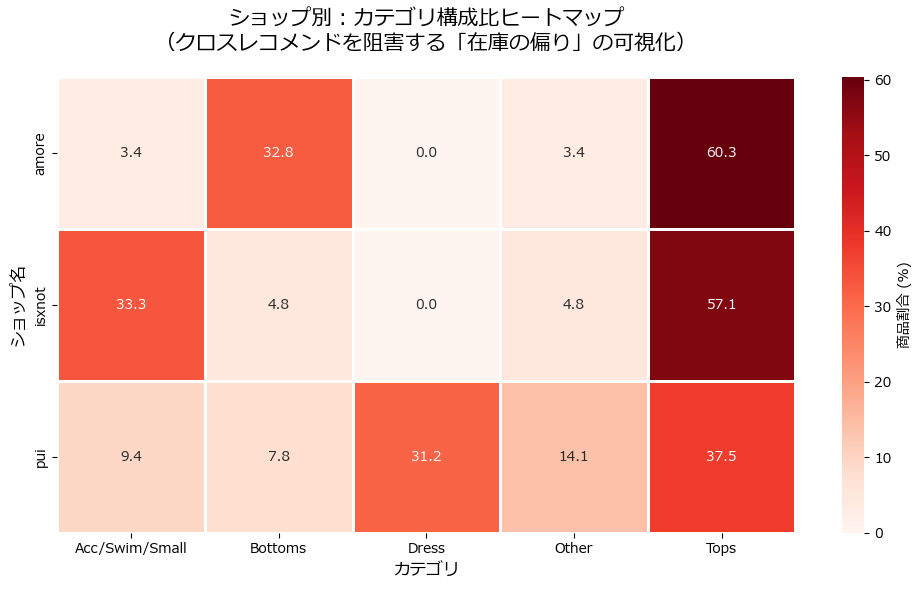

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ※dfは前回のクレンジング＆分類が完了した状態のものを使用します

# ショップごとのカテゴリ割合（%）を計算する
category_ratios = pd.crosstab(df['ショップ名'], df['Category'], normalize='index') * 100

# グラフの描画設定
plt.rcParams['font.family'] = 'Meiryo'
plt.figure(figsize=(10, 6))

# ヒートマップの作成（赤色が濃いほど割合が高い）
sns.heatmap(category_ratios, annot=True, fmt=".1f", cmap="Reds", 
            cbar_kws={'label': '商品割合 (%)'}, linewidths=1, linecolor='white')

plt.title("ショップ別：カテゴリ構成比ヒートマップ\n（クロスレコメンドを阻害する「在庫の偏り」の可視化）", fontsize=15, pad=20)
plt.ylabel("ショップ名", fontsize=12)
plt.xlabel("カテゴリ", fontsize=12)

# スライド用に画像を保存
plt.tight_layout()
plt.savefig("cross_recommend_heatmap.png", dpi=300)
plt.show()